In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('car_price.csv')
print(f" Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(df.head())

 Data loaded: 72435 rows, 10 columns
  model    year    price transmission  mileage fuelType    tax   mpg  \
0    A1  2017.0  12500.0       Manual  15735.0   Petrol  150.0  55.4   
1    A6  2016.0  16500.0    Automatic  36203.0   Diesel   20.0  64.2   
2    A1  2016.0  11000.0       Manual  29946.0   Petrol   30.0  55.4   
3    A4  2017.0  16800.0    Automatic  25952.0   Diesel  145.0  67.3   
4    A3  2019.0  17300.0       Manual   1998.0   Petrol  145.0  49.6   

   engineSize  Make  
0         1.4  audi  
1         2.0  audi  
2         1.4  audi  
3         2.0  audi  
4         1.0  audi  


TASK 1: EDA

Missing Values:
model           3621
year            3622
price           3621
transmission    3623
mileage         3622
fuelType        3622
tax             3621
mpg             3621
engineSize      3622
Make            3621
dtype: int64

Dataset Shape: (72435, 10)

Data Types:
model            object
year            float64
price           float64
transmission     object
mileage         float64
fuelType         object
tax             float64
mpg             float64
engineSize      float64
Make             object
dtype: object


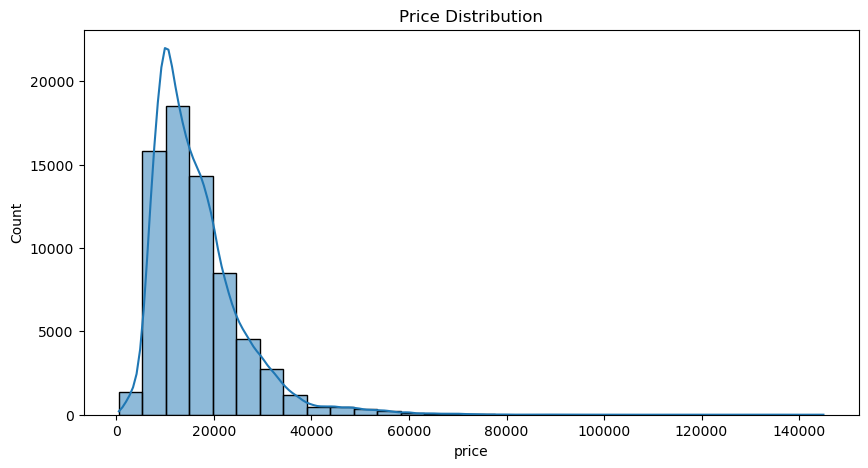

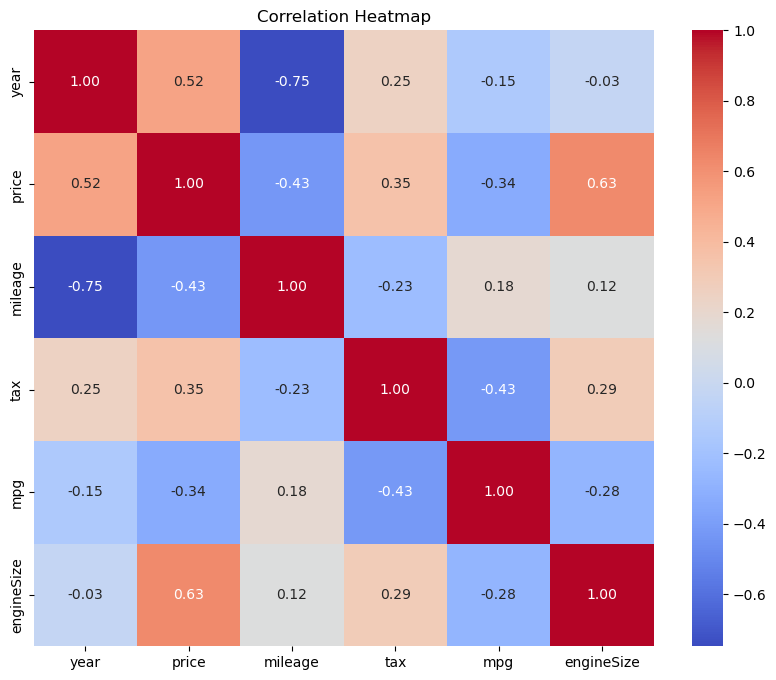

In [2]:

print("TASK 1: EDA")


print("\nMissing Values:")
print(df.isnull().sum())

print(f"\nDataset Shape: {df.shape}")
print(f"\nData Types:\n{df.dtypes}")

# Price Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=30, kde=True)
plt.title('Price Distribution')
plt.show()

# Correlation
numeric_cols = df.select_dtypes(include=['number']).columns
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [3]:
print("TASK 2: PREPROCESSING")

df_clean = df.copy()
print(f"\n1️ Before cleaning: {df_clean.shape[0]} rows")
df_clean = df_clean.dropna(subset=['price', 'year', 'mileage'])
print(f"   After dropping NaN in key columns: {df_clean.shape[0]} rows")

numeric_cols = df_clean.select_dtypes(include=['number']).columns
for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mean())

categorical_cols = ['transmission', 'fuelType', 'Make', 'model']
for col in categorical_cols:
    if col in df_clean.columns:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print(f"   Total missing values now: {df_clean.isnull().sum().sum()}")

#One-Hot Encoding
df_encoded = pd.get_dummies(df_clean, columns=['transmission', 'fuelType', 'Make', 'model'], drop_first=True)
print(f"\n2️ After encoding: {df_encoded.shape}")

# Scaling
X = df_encoded.drop('price', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print("3️ Scaling applied")

print(f"\n Final check - NaN values: {X_scaled.isnull().sum().sum()}")

TASK 2: PREPROCESSING

1️ Before cleaning: 72435 rows
   After dropping NaN in key columns: 62139 rows
   Total missing values now: 0

2️ After encoding: (62139, 163)
3️ Scaling applied

 Final check - NaN values: 0


In [4]:
print("TASK 3: CREATE TARGETS")

# Regression Target
y_reg = df_clean['price'].reset_index(drop=True)
X = X_scaled.reset_index(drop=True)

print(f" Regression Target: {y_reg.shape}")

# Classification Target
p33 = df_clean['price'].quantile(0.33)
p66 = df_clean['price'].quantile(0.66)

bins = [0, p33, p66, float('inf')]
labels = ['Cheap', 'Moderate', 'Expensive']

df_clean['price_category'] = pd.cut(df_clean['price'], bins=bins, labels=labels)

print(f"\nClassification Distribution:")
print(df_clean['price_category'].value_counts())

le = LabelEncoder()
y_clf = le.fit_transform(df_clean['price_category'])

print(f"\n Classes: {dict(zip(le.classes_, range(len(le.classes_))))}")

TASK 3: CREATE TARGETS
 Regression Target: (62139,)

Classification Distribution:
price_category
Expensive    20996
Moderate     20636
Cheap        20507
Name: count, dtype: int64

 Classes: {'Cheap': 0, 'Expensive': 1, 'Moderate': 2}


TASK 4: LINEAR REGRESSION

R² Score: 0.8677
RMSE: 3285.32


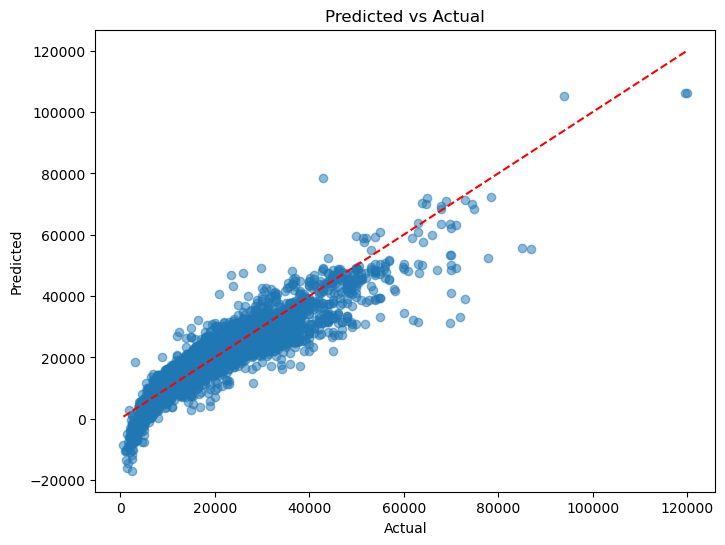


 Task 4 Complete


In [5]:
print("TASK 4: LINEAR REGRESSION")

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# Train
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict
y_pred = lr_model.predict(X_test)

# Evaluate
print(f"\nR² Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Predicted vs Actual')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

print("\n Task 4 Complete")

TASK 5: KNN CLASSIFICATION
Best Params: {'metric': 'manhattan', 'n_neighbors': 5}

Accuracy: 0.8870

Classification Report:
              precision    recall  f1-score   support

       Cheap       0.92      0.91      0.91      4102
   Expensive       0.91      0.92      0.92      4199
    Moderate       0.83      0.83      0.83      4127

    accuracy                           0.89     12428
   macro avg       0.89      0.89      0.89     12428
weighted avg       0.89      0.89      0.89     12428



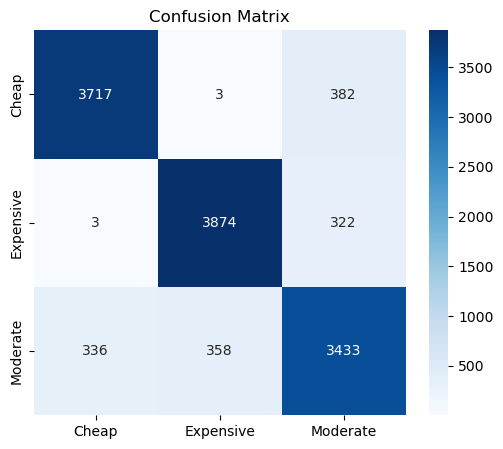


 Task 5 Complete


In [6]:
print("TASK 5: KNN CLASSIFICATION")

# Split
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# Grid Search
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_clf, y_train_clf)

print(f"Best Params: {grid_search.best_params_}")

# Evaluate
best_knn = grid_search.best_estimator_
y_pred_clf = best_knn.predict(X_test_clf)

print(f"\nAccuracy: {accuracy_score(y_test_clf, y_pred_clf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_clf, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test_clf, y_pred_clf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.show()

print("\n Task 5 Complete")

TASK 6 & 7: DISCUSSION & VISUALIZATIONS

 Discussion:
1. Regression R²: 0.8677
2. Classification Accuracy: 0.8870
3. Classification is easier because it groups prices into broad categories


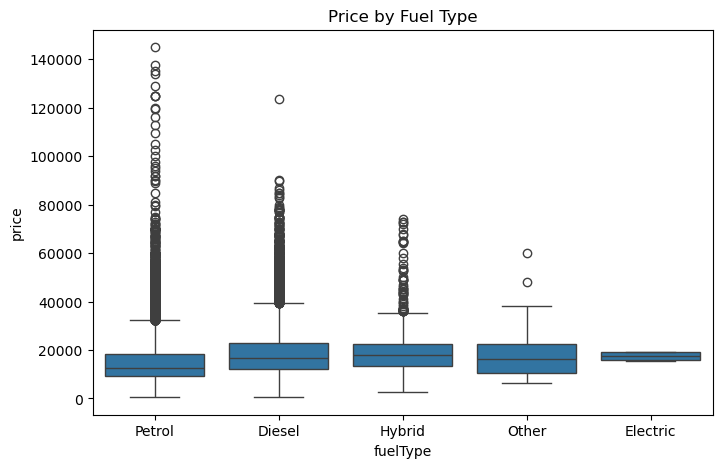

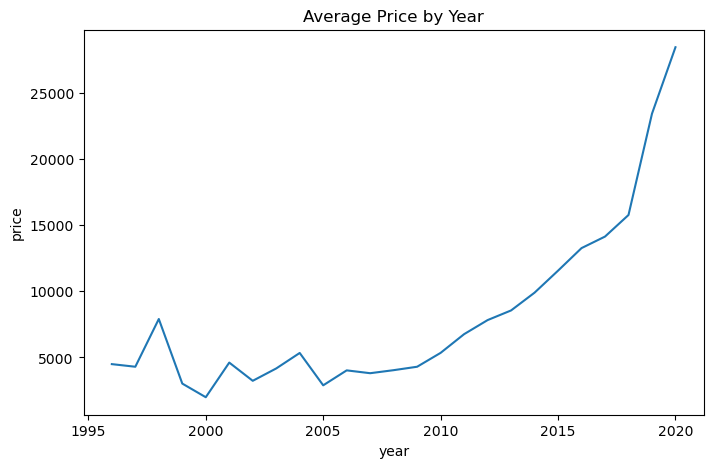


 ALL TASKS COMPLETE!


In [7]:
print("TASK 6 & 7: DISCUSSION & VISUALIZATIONS")

print("\n Discussion:")
print(f"1. Regression R²: {r2_score(y_test, y_pred):.4f}")
print(f"2. Classification Accuracy: {accuracy_score(y_test_clf, y_pred_clf):.4f}")
print("3. Classification is easier because it groups prices into broad categories")

# Additional Plots
plt.figure(figsize=(8, 5))
sns.boxplot(x='fuelType', y='price', data=df_clean)
plt.title('Price by Fuel Type')
plt.show()

plt.figure(figsize=(8, 5))
sns.lineplot(x='year', y='price', data=df_clean, errorbar=None)
plt.title('Average Price by Year')
plt.show()

print("\n ALL TASKS COMPLETE!")

In [8]:
# imports  (3mlna el imports el asasia el hya7tagoha f el project de)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json

from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold, cross_val_score,
    GridSearchCV, learning_curve
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB
from sklearn.ensemble import VotingRegressor, VotingClassifier, RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix
)


warnings.filterwarnings('ignore')

TASK 1: Exploratory Data Analysis

[1A] Missing Values:
Name                 0
Country              0
Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
dtype: int64

[1B] Skewness of 'Value Per M$': 7.98  (highly right-skewed)


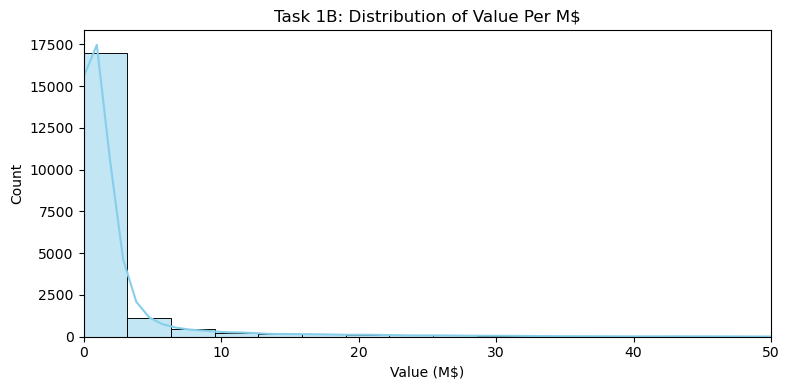


[1C] Correlation matrix (numerical features):
                   Value Per M$
Value Per M$           1.000000
Overall_Rating         0.560648
Future Potential       0.500964
Total_Stats Score      0.385062
Age                    0.142276


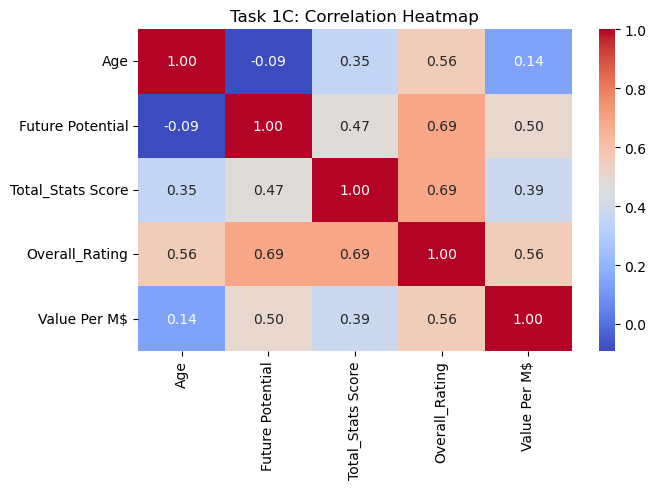


[1D] Average Overall_Rating per Position (top 10):
Position
SW     75.000000
RF     75.000000
CF     66.042857
LW     64.345979
CDM    64.234168
LM     64.172009
RWB    64.063973
LWB    64.043333
RM     63.907731
RW     63.718529
Name: Overall_Rating, dtype: float64


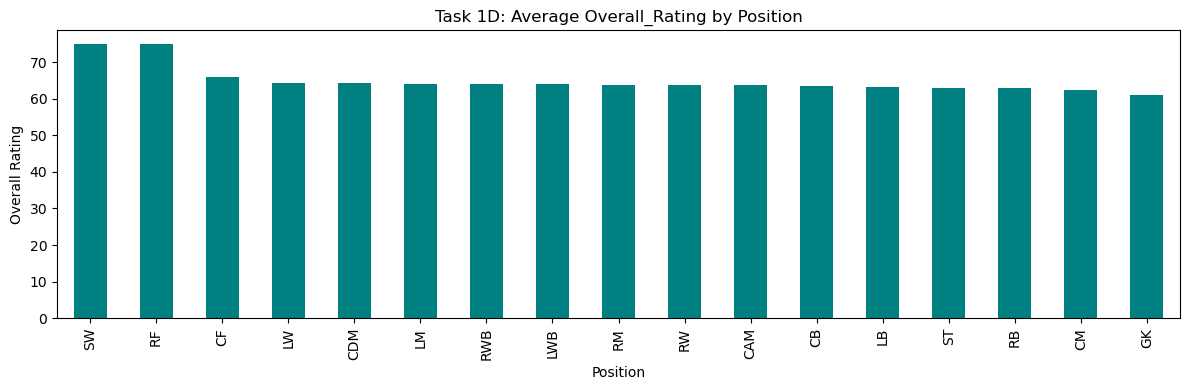

In [9]:
# TASK 1 Exploratory Data Analysis (3mlna EDA bas 3ashan nefham el data kwayes abl ma ne5osh f el modeling)
print("TASK 1: Exploratory Data Analysis")

df_full = pd.read_csv('Fifa.csv')   # <-- 7tena el path 
 
# 1A. checking missing values ( 3shan nshof lo fy ay null values hy2t2rna f el training)))
print("\n[1A] Missing Values:")
print(df_full.isnull().sum())
 
# 1B. checking distribution of 'Value Per M$' 
skew_val = df_full['Value Per M$'].skew()
print(f"\n[1B] Skewness of 'Value Per M$': {skew_val:.2f}  (highly right-skewed)")
 
plt.figure(figsize=(8, 4))
sns.histplot(df_full['Value Per M$'], bins=60, kde=True, color='skyblue')
plt.title("Task 1B: Distribution of Value Per M$")
plt.xlabel("Value (M$)")
plt.xlim(0, 50)
plt.tight_layout()
plt.show()
 
# 1C. correlation mat ( 3ashan nshof el features el ktar 3la2a bel target value)
num_cols = ['Age', 'Future Potential', 'Total_Stats Score', 'Overall_Rating', 'Value Per M$']
corr = df_full[num_cols].corr()
print("\n[1C] Correlation matrix (numerical features):")
print(corr[['Value Per M$']].sort_values('Value Per M$', ascending=False))
 
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Task 1C: Correlation Heatmap")
plt.tight_layout()
plt.show()
 
# 1D. avg rating per position -> 3ashan nshof ay centers f el 3ab 3aleeha akter
pos_avg = df_full.groupby('Position')['Overall_Rating'].mean().sort_values(ascending=False)
print("\n[1D] Average Overall_Rating per Position (top 10):")
print(pos_avg.head(10))
 
plt.figure(figsize=(12, 4))
pos_avg.plot(kind='bar', color='teal')
plt.title("Task 1D: Average Overall_Rating by Position")
plt.ylabel("Overall Rating")
plt.tight_layout()
plt.show() 

In [10]:
# TASK 2 Data Preprocessing (3mlna preprocessing 3ashan ngezz el data wa n8yer el format 3ashan el model)
print("TASK 2: Data Preprocessing")
 
num_features = ['Age', 'Future Potential', 'Total_Stats Score']
cat_features  = ['Position', 'Country', 'Team']
 
# regression target (el value hya el thing el 3ayezin ne2mha)
X_reg = df_full.drop(columns=['Value Per M$', 'Name'])
y_reg = df_full['Value Per M$']
 
# creating classification target by splitting overall rating into tiers (Low, Mid, High, Elite)
p25, p50, p75 = df_full['Overall_Rating'].quantile([0.25, 0.50, 0.75])
 
def classify_tier(r):
    if r  <= p25:  return 'Low'
    elif r  <= p50: return 'Mid'
    elif r  <= p75: return 'High'
    else:          return 'Elite'
 
df_full['Tier'] = df_full['Overall_Rating'].apply(classify_tier)
y_cls = df_full['Tier']
 
# 80/20 train oR test split (7tet 20% lel testing wa 80% lel training)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
 
# for classification, we drop Overall_Rating cause we already used it to make the labels
X_cls = df_full.drop(columns=['Value Per M$', 'Name', 'Tier', 'Overall_Rating'])
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)
 
print(f"Train size: {len(X_train_reg)}, Test size: {len(X_test_reg)}")
 
# outlier handling using IQR (clip outliers 3ashan may2t2rsh 3la el model kteer, 3mlnah 3la train bs)
def clip_outliers(train_df, test_df, cols):
    tr, te = train_df.copy(), test_df.copy()
    for col in cols:
        q1, q3 = tr[col].quantile(0.25), tr[col].quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        tr[col] = tr[col].clip(lo, hi)
        te[col] = te[col].clip(lo, hi)
    return tr, te
 
X_train_reg, X_test_reg   = clip_outliers(X_train_reg, X_test_reg, num_features)
X_train_cls, X_test_cls   = clip_outliers(X_train_cls, X_test_cls, num_features)
 
print("Outlier clipping applied (IQR method, fit on train only))") 

TASK 2: Data Preprocessing
Train size: 15733, Test size: 3934
Outlier clipping applied (IQR method, fit on train only))


TASK 3: Classification Target Creation
Thresholds (based on Overall_Rating percentiles):
  Low  :  <= 58
  Mid  : 58 – 63
  High : 63 – 68
  Elite:  > 68

Class distribution in training set:
Tier
Low      4454
Mid      4081
Elite    3760
High     3438
Name: count, dtype: int64


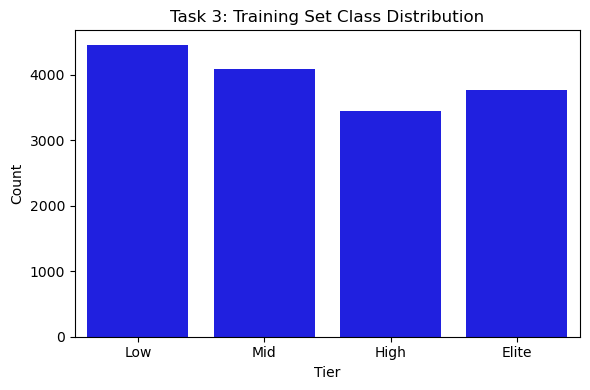

In [11]:
# TASK 3  Create Classification Target (3mlna el tiers bas 3ashan el classification task)
print("TASK 3: Classification Target Creation")
 
print(f"Thresholds (based on Overall_Rating percentiles):")
print(f"  Low  :  <= {p25:.0f}")
print(f"  Mid  : {p25:.0f} – {p50:.0f}")
print(f"  High : {p50:.0f} – {p75:.0f}")
print(f"  Elite:  > {p75:.0f}")
 
print("\nClass distribution in training set:")
print(y_train_cls.value_counts())
 
# plotting el distribution 3ashan nshof lo fy imbalance wala la2
plt.figure(figsize=(6, 4))
order = ['Low', 'Mid', 'High', 'Elite']
sns.countplot(x=y_train_cls, order=order, color='blue')  
plt.title("Task 3: Training Set Class Distribution")
plt.xlabel("Tier")
plt.ylabel("Count")
plt.tight_layout()
plt.show() 

TASK 4: Polynomial Regression  & Regularization

Baseline Linear Regression:
  Train — RMSE: 4.706  R²: 0.5598
  Test  — MAE: 2.596   MSE: 29.835   RMSE: 5.462   R²: 0.5190

Degree Sweep:
  Degree 1: Train R²=0.5598, Test R²=0.5190, Gap=0.0407
  Degree 2: Train R²=0.6968, Test R²=0.6560, Gap=0.0408
  Degree 3: Train R²=0.8329, Test R²=0.7986, Gap=0.0343
  Degree 4: Train R²=0.8984, Test R²=0.8809, Gap=0.0175


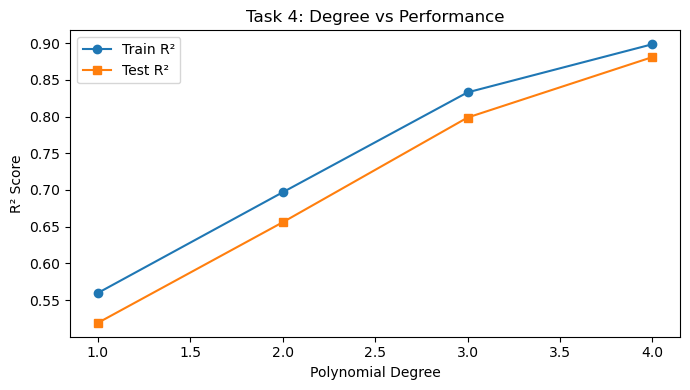


Best Degree: 4  (highest Test R², gap = 0.0175)

Regularization sweep using degree=3:


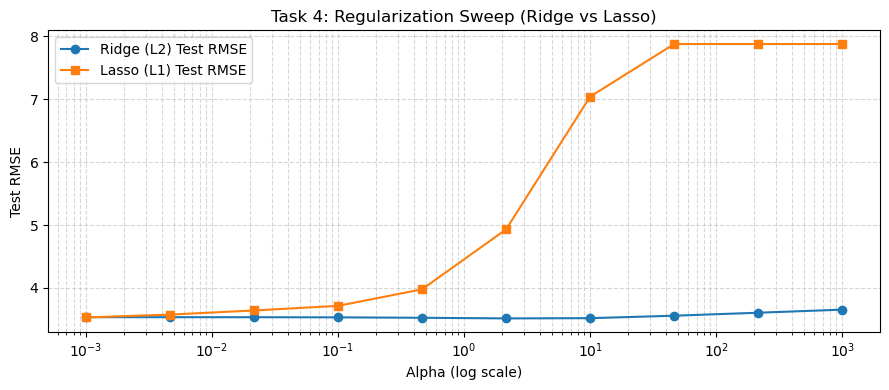

Best Ridge alpha: 2.1544  (Test RMSE: 3.5153)
Best Lasso alpha: 0.0010  (Test RMSE: 3.5306)

Lasso zeroed 996 / 1196 features.
Examples of zeroed features: ['Position_LM' 'Position_SW' 'Country_Afghanistan' 'Country_Albania'
 'Country_Angola' 'Country_Argentina']

Task 4 complete. Variables ready: best_d, best_ridge_a, best_lasso_a


In [12]:
# TASK 4 — Polynomial Regression + Regularization (jrbna poly features wa regularization 3ashan nshof el best model)
print("TASK 4: Polynomial Regression  & Regularization")
 
# Pipeline builder ( 3mlna pipeline 3ashan el preprocessing wa el model ysh3'lu m3 b3d mn gher ma n3mlha manually)
def make_poly_pipe(degree, model):
    num_poly_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('poly',   PolynomialFeatures(degree=degree, include_bias=False))
    ])
    pre = ColumnTransformer([
        ('num_poly', num_poly_pipe,   num_features),       # poly 3la el 3 num features
        ('num_lin',  StandardScaler(), ['Overall_Rating']), # linear bas lel rating
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ])
    return Pipeline([('pre', pre), ('model', model)])
 
# Baseline Linear Regression (el model el asasy mn gher poly)
base = make_poly_pipe(1, LinearRegression())
base.fit(X_train_reg, y_train_reg)
yp_tr = base.predict(X_train_reg)
yp_te = base.predict(X_test_reg)
 
print("\nBaseline Linear Regression:")
print(f"  Train — RMSE: {np.sqrt(mean_squared_error(y_train_reg, yp_tr)):.3f}  R²: {r2_score(y_train_reg, yp_tr):.4f}")
print(f"  Test  — MAE: {mean_absolute_error(y_test_reg, yp_te):.3f}   "
      f"MSE: {mean_squared_error(y_test_reg, yp_te):.3f}   "
      f"RMSE: {np.sqrt(mean_squared_error(y_test_reg, yp_te)):.3f}   "
      f"R²: {r2_score(y_test_reg, yp_te):.4f}")
 
# Degree Sweep -> jrbna degrees mo5talfa 3ashan nshof el best one
print("\nDegree Sweep:")
degrees = [1, 2, 3, 4]
train_r2, test_r2 = [], []
 
for d in degrees:
    pipe = make_poly_pipe(d, LinearRegression())
    pipe.fit(X_train_reg, y_train_reg)
    tr = r2_score(y_train_reg, pipe.predict(X_train_reg))
    te = r2_score(y_test_reg,  pipe.predict(X_test_reg))
    train_r2.append(tr)
    test_r2.append(te)
    print(f"  Degree {d}: Train R²={tr:.4f}, Test R²={te:.4f}, Gap={tr-te:.4f}")
 
plt.figure(figsize=(7, 4))
plt.plot(degrees, train_r2, marker='o', label='Train R²')
plt.plot(degrees, test_r2,  marker='s', label='Test R²')
plt.xlabel('Polynomial Degree')
plt.ylabel('R² Score')
plt.title('Task 4: Degree vs Performance')
plt.legend()
plt.tight_layout()
plt.show()
 
best_d = degrees[np.argmax(test_r2)]
print(f"\nBest Degree: {best_d}  (highest Test R², gap = {train_r2[best_d-1]-test_r2[best_d-1]:.4f})")
 
# Regularization sweep (Ridge vs Lasso) -> grbna alphas mo5talfa 3ashan nla2y el optimal alpha
reg_degree = min(best_d, 3)
print(f"\nRegularization sweep using degree={reg_degree}:")
 
alphas = np.logspace(-3, 3, 10)
ridge_rmse, lasso_rmse = [], []
 
for a in alphas:
    rp = make_poly_pipe(reg_degree, Ridge(alpha=a))
    rp.fit(X_train_reg, y_train_reg)
    ridge_rmse.append(np.sqrt(mean_squared_error(y_test_reg, rp.predict(X_test_reg))))
 
    lp = make_poly_pipe(reg_degree, Lasso(alpha=a, max_iter=10000))
    lp.fit(X_train_reg, y_train_reg)
    lasso_rmse.append(np.sqrt(mean_squared_error(y_test_reg, lp.predict(X_test_reg))))
 
plt.figure(figsize=(9, 4))
plt.semilogx(alphas, ridge_rmse, marker='o', label='Ridge (L2) Test RMSE')
plt.semilogx(alphas, lasso_rmse, marker='s', label='Lasso (L1) Test RMSE')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Test RMSE')
plt.title('Task 4: Regularization Sweep (Ridge vs Lasso)')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout()
plt.show()
 
best_ridge_a = alphas[np.argmin(ridge_rmse)]
best_lasso_a = alphas[np.argmin(lasso_rmse)]
print(f"Best Ridge alpha: {best_ridge_a:.4f}  (Test RMSE: {min(ridge_rmse):.4f})")
print(f"Best Lasso alpha: {best_lasso_a:.4f}  (Test RMSE: {min(lasso_rmse):.4f})")
 
# Lasso zeroed features -> Lasso 3melt feature selection w 8yyaret el features el mesh mohema
final_lasso = make_poly_pipe(reg_degree, Lasso(alpha=best_lasso_a, max_iter=10000))
final_lasso.fit(X_train_reg, y_train_reg)
 
poly_names = (final_lasso.named_steps['pre']
                          .named_transformers_['num_poly']['poly']
                          .get_feature_names_out(num_features))
cat_names  = (final_lasso.named_steps['pre']
                          .named_transformers_['cat']
                          .get_feature_names_out(cat_features))
all_names  = np.concatenate([poly_names, ['Overall_Rating'], cat_names])
zeroed     = all_names[final_lasso.named_steps['model'].coef_ == 0]
 
print(f"\nLasso zeroed {len(zeroed)} / {len(all_names)} features.")
print(f"Examples of zeroed features: {zeroed[:6]}")
print("\nTask 4 complete. Variables ready: best_d, best_ridge_a, best_lasso_a")

TASK 5: Logistic Regression

Baseline Logistic Regression:
              precision    recall  f1-score   support

         Low       0.88      0.88      0.88       940
         Mid       0.71      0.68      0.69       859
        High       0.88      0.90      0.89      1114
       Elite       0.73      0.74      0.73      1021

    accuracy                           0.80      3934
   macro avg       0.80      0.80      0.80      3934
weighted avg       0.80      0.80      0.80      3934



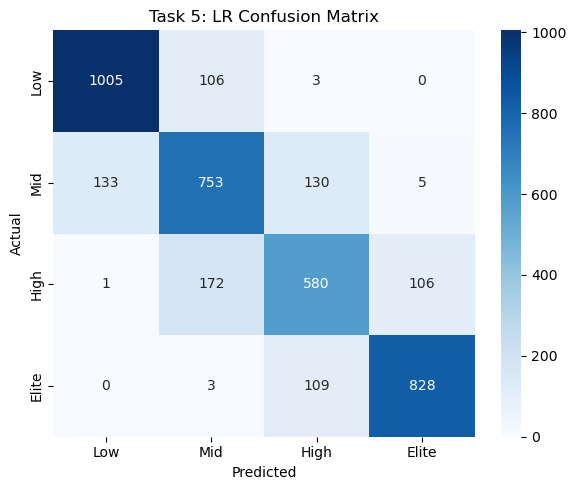

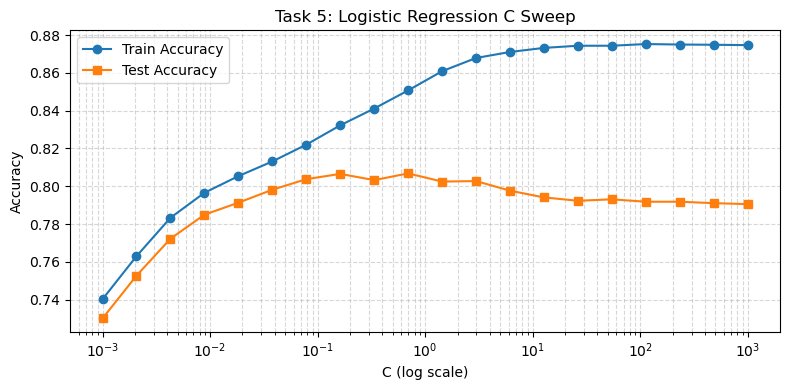

Best C: 0.6952
L2 Test Accuracy: 0.8068
L1 Test Accuracy: 0.8010


In [13]:
# TASK 5 — Logistic Regression (classification bas using logistic reg)
print("TASK 5: Logistic Regression")
 
cls_pre = ColumnTransformer([
    ('num', StandardScaler(), num_features), 
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
])
 
# Baseline LR
lr_pipe = Pipeline([
    ('pre', cls_pre),
    ('lr',  LogisticRegression(max_iter=5000, C=1.0, solver='lbfgs'))
    # sklearn 1.8 shayel el multi_class param, lbfgs byshoghlha automatically
])
lr_pipe.fit(X_train_cls, y_train_cls)
y_pred_lr = lr_pipe.predict(X_test_cls)
 
print("\nBaseline Logistic Regression:")
print(classification_report(y_test_cls, y_pred_lr, target_names=order))
 
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_cls, y_pred_lr, labels=order),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=order, yticklabels=order)
plt.title("Task 5: LR Confusion Matrix")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout(); plt.show()
 
# C sweep -> jrbna values mo5talfa lel C (inverse regularization) 3ashan nla2y el best one
Cs = np.logspace(-3, 3, 20)
train_acc_lr, test_acc_lr = [], []
 
X_tr_proc = cls_pre.fit_transform(X_train_cls)
X_te_proc  = cls_pre.transform(X_test_cls)
 
for c in Cs:
    clf = LogisticRegression(max_iter=5000, C=c, solver='lbfgs')
    clf.fit(X_tr_proc, y_train_cls)
    train_acc_lr.append(accuracy_score(y_train_cls, clf.predict(X_tr_proc)))
    test_acc_lr.append( accuracy_score(y_test_cls,  clf.predict(X_te_proc)))
 
plt.figure(figsize=(8, 4))
plt.semilogx(Cs, train_acc_lr, marker='o', label='Train Accuracy')
plt.semilogx(Cs, test_acc_lr,  marker='s', label='Test Accuracy')
plt.xlabel('C (log scale)'); plt.ylabel('Accuracy')
plt.title('Task 5: Logistic Regression C Sweep')
plt.legend(); plt.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout(); plt.show()
 
best_C = Cs[np.argmax(test_acc_lr)]
print(f"Best C: {best_C:.4f}")
 
# L1 vs L2 (using lbfgs for L2 and saga for L1)
lr_l2 = LogisticRegression(max_iter=5000, C=best_C, solver='lbfgs')

# التعديل هنا: ضفنا penalty='elasticnet' عشان l1_ratio=1 يشتغل صح
lr_l1 = LogisticRegression(max_iter=5000, C=best_C, solver='saga', penalty='elasticnet', l1_ratio=1)

lr_l2.fit(X_tr_proc, y_train_cls)
lr_l1.fit(X_tr_proc, y_train_cls)
print(f"L2 Test Accuracy: {accuracy_score(y_test_cls, lr_l2.predict(X_te_proc)):.4f}")
print(f"L1 Test Accuracy: {accuracy_score(y_test_cls, lr_l1.predict(X_te_proc)):.4f}")

TASK 6: Naïve Bayes Classification

GaussianNB (numerical features only):
              precision    recall  f1-score   support

         Low       0.86      0.80      0.83       940
         Mid       0.62      0.53      0.57       859
        High       0.82      0.81      0.81      1114
       Elite       0.59      0.70      0.64      1021

    accuracy                           0.72      3934
   macro avg       0.72      0.71      0.71      3934
weighted avg       0.72      0.72      0.72      3934



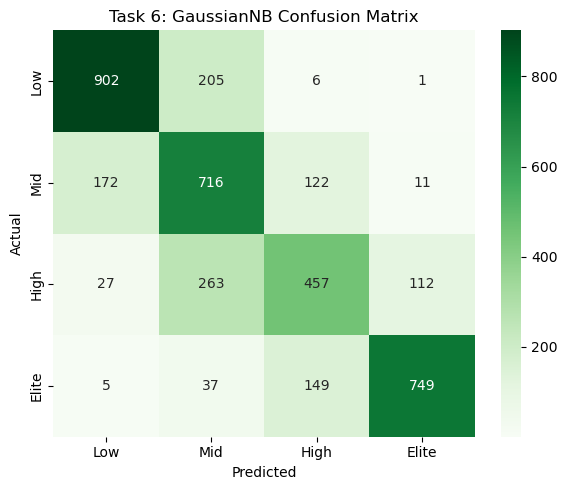


BernoulliNB (OHE categorical features):
              precision    recall  f1-score   support

         Low       0.55      0.66      0.60       940
         Mid       0.38      0.26      0.31       859
        High       0.55      0.68      0.61      1114
       Elite       0.41      0.34      0.37      1021

    accuracy                           0.50      3934
   macro avg       0.47      0.48      0.47      3934
weighted avg       0.48      0.50      0.48      3934



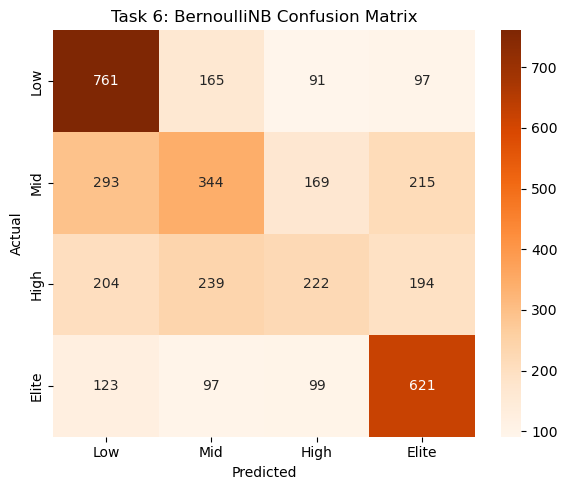


ComplementNB (OHE categorical features):
              precision    recall  f1-score   support

         Low       0.54      0.69      0.60       940
         Mid       0.35      0.27      0.30       859
        High       0.55      0.67      0.60      1114
       Elite       0.41      0.29      0.34      1021

    accuracy                           0.49      3934
   macro avg       0.46      0.48      0.46      3934
weighted avg       0.47      0.49      0.47      3934



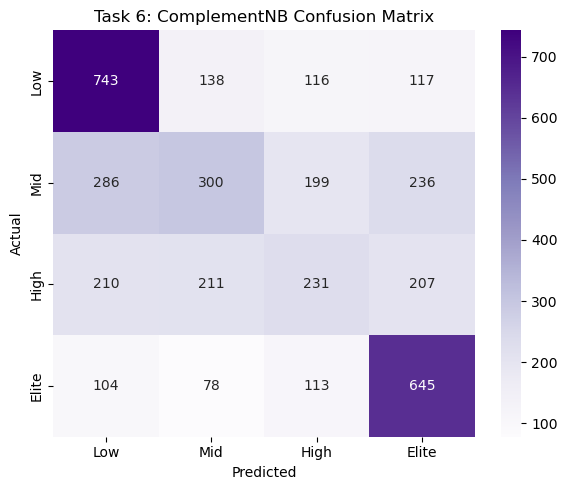


GaussianNB Scaling Sensitivity:
  Scaled accuracy  : 0.7178
  Unscaled accuracy: 0.7178
  Scaling does NOT change GaussianNB accuracy. It models class-conditional
  Gaussian distributions — scaling the features shifts the fitted mean and
  variance proportionally, leaving the decision boundaries identical.


In [14]:
# TASK 6 — Naïve Bayes (jrbna GaussianNB, BernoulliNB, wa ComplementNB)
print("TASK 6: Naïve Bayes Classification")
 
# GaussianNB for numerical features only (7tet scaler 3ashan el features yb2a 3la nafs el scale)
gnb_pipe = Pipeline([('scaler', StandardScaler()), ('nb', GaussianNB())])
gnb_pipe.fit(X_train_cls[num_features], y_train_cls)
y_pred_gnb = gnb_pipe.predict(X_test_cls[num_features])
 
print("\nGaussianNB (numerical features only):")
print(classification_report(y_test_cls, y_pred_gnb, target_names=order))
 
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_cls, y_pred_gnb, labels=order),
            annot=True, fmt='d', cmap='Greens',
            xticklabels=order, yticklabels=order)
plt.title("Task 6: GaussianNB Confusion Matrix")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout(); plt.show()
 
# BernoulliNB & ComplementNB for OHE categorical features (3mlna one-hot encoding lel categorical cols)
ohe_only = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_tr_cat = ohe_only.fit_transform(X_train_cls[cat_features])
X_te_cat = ohe_only.transform(X_test_cls[cat_features])
 
for name, nb_model, cmap in [('BernoulliNB',  BernoulliNB(),  'Oranges'),
                               ('ComplementNB', ComplementNB(), 'Purples')]:
    nb_model.fit(X_tr_cat, y_train_cls)
    y_pred_nb = nb_model.predict(X_te_cat)
    print(f"\n{name} (OHE categorical features):")
    print(classification_report(y_test_cls, y_pred_nb, target_names=order))
    plt.figure(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_test_cls, y_pred_nb, labels=order),
                annot=True, fmt='d', cmap=cmap,
                xticklabels=order, yticklabels=order)
    plt.title(f"Task 6: {name} Confusion Matrix")
    plt.ylabel("Actual"); plt.xlabel("Predicted")
    plt.tight_layout(); plt.show()
 
# Scaling sensitivity check -> GaussianNB msh byt2tr 3la scaling 3ashan el distributions bytghyyr proportionally
scaler_tmp   = StandardScaler()
gnb_scaled   = GaussianNB()
gnb_unscaled = GaussianNB()
 
gnb_scaled.fit(scaler_tmp.fit_transform(X_train_cls[num_features]), y_train_cls)
gnb_unscaled.fit(X_train_cls[num_features], y_train_cls)
 
acc_s = accuracy_score(y_test_cls, gnb_scaled.predict(scaler_tmp.transform(X_test_cls[num_features])))
acc_u = accuracy_score(y_test_cls, gnb_unscaled.predict(X_test_cls[num_features]))
print(f"\nGaussianNB Scaling Sensitivity:")
print(f"  Scaled accuracy  : {acc_s:.4f}")
print(f"  Unscaled accuracy: {acc_u:.4f}")
print("  Scaling does NOT change GaussianNB accuracy. It models class-conditional")
print("  Gaussian distributions — scaling the features shifts the fitted mean and")
print("  variance proportionally, leaving the decision boundaries identical.")

TASK 7: Model Evaluation with Cross-Validation

[7A] Ridge Regression — 5-Fold CV RMSE:
  Fold 1: 2.5260
  Fold 2: 2.7003
  Fold 3: 2.2797
  Fold 4: 2.1013
  Fold 5: 2.7895
  Mean: 2.4794  |  Std: 0.2569


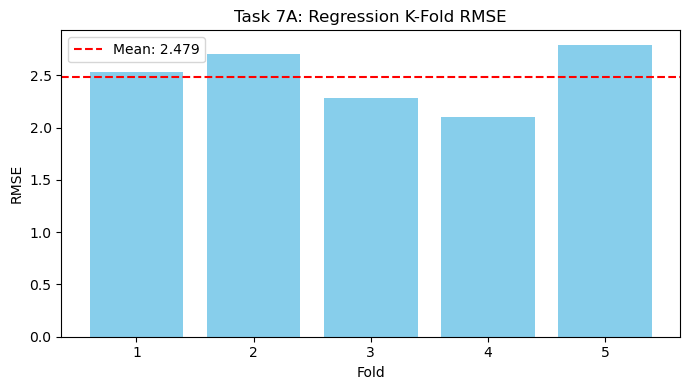


[7B] Stratified K-Fold Classification Accuracy:
  Logistic Regression: Mean=0.8069  Std=0.0059  Folds=[0.8001 0.8001 0.8106 0.815  0.8086]
  GaussianNB         : Mean=0.7175  Std=0.0135  Folds=[0.721  0.7061 0.7166 0.7409 0.7028]


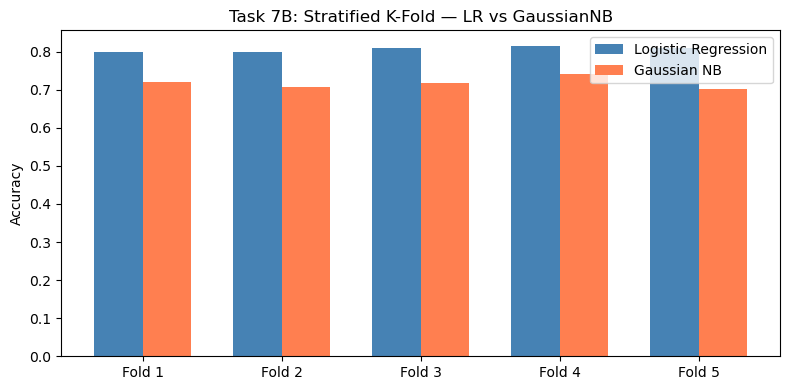

In [15]:
# TASK 7 — Cross-Validation (3mlna CV 3ashan nshof el model stability wa generalization)
print("TASK 7: Model Evaluation with Cross-Validation")
 
# 7A. K-Fold for Regression
best_reg_pipe = make_poly_pipe(best_d, Ridge(alpha=best_ridge_a))
kf = KFold(n_splits=5, shuffle=True, random_state=42)
 
cv_rmse = -cross_val_score(
    best_reg_pipe, X_train_reg, y_train_reg,
    cv=kf, scoring='neg_root_mean_squared_error'
)
print(f"\n[7A] Ridge Regression — 5-Fold CV RMSE:")
for i, v in enumerate(cv_rmse, 1):
    print(f"  Fold {i}: {v:.4f}")
print(f"  Mean: {cv_rmse.mean():.4f}  |  Std: {cv_rmse.std():.4f}")
 
plt.figure(figsize=(7, 4))
plt.bar(range(1, 6), cv_rmse, color='skyblue')
plt.axhline(cv_rmse.mean(), color='red', ls='--', label=f'Mean: {cv_rmse.mean():.3f}')
plt.xlabel('Fold'); plt.ylabel('RMSE')
plt.title('Task 7A: Regression K-Fold RMSE')
plt.legend(); plt.tight_layout(); plt.show()
 
# 7B. Stratified K-Fold for Classification (stratify 3ashan el folds yb2a fy nafs el distribution)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
best_lr_pipe = Pipeline([
    ('pre', ColumnTransformer([
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ])),
    ('lr', LogisticRegression(max_iter=5000, C=best_C, solver='lbfgs'))
])
best_gnb_pipe = Pipeline([('scaler', StandardScaler()), ('nb', GaussianNB())])
 
cv_lr  = cross_val_score(best_lr_pipe,  X_train_cls,               y_train_cls, cv=skf, scoring='accuracy')
cv_gnb = cross_val_score(best_gnb_pipe, X_train_cls[num_features], y_train_cls, cv=skf, scoring='accuracy')
 
print(f"\n[7B] Stratified K-Fold Classification Accuracy:")
print(f"  Logistic Regression: Mean={cv_lr.mean():.4f}  Std={cv_lr.std():.4f}  Folds={np.round(cv_lr,4)}")
print(f"  GaussianNB         : Mean={cv_gnb.mean():.4f}  Std={cv_gnb.std():.4f}  Folds={np.round(cv_gnb,4)}")
 
x = np.arange(5); w = 0.35
plt.figure(figsize=(8, 4))
plt.bar(x - w/2, cv_lr,  w, label='Logistic Regression', color='steelblue')
plt.bar(x + w/2, cv_gnb, w, label='Gaussian NB',         color='coral')
plt.xticks(x, [f'Fold {i+1}' for i in range(5)])
plt.ylabel('Accuracy')
plt.title('Task 7B: Stratified K-Fold — LR vs GaussianNB')
plt.legend(); plt.tight_layout(); plt.show()

In [16]:
# TASK 8 — Analysis & Discussion (el conclusion el 7slna 3liha mn el results)
print("TASK 8: Analysis and Discussion")

print("""
8.1 Model Comparison
• Regression: Ridge + poly degree 4 da kan el a7san. El poly features by3rf el non-linear relations (zay age x potential),
  wa el L2 regularization bymn3 el overfitting. El target knt right-skewed kteer (some players have crazy high values),
  so el RMSE kber shwaya 3ashan el outliers.
 
• Classification: Logistic Regression (~81%) da kan b3eed 3an el Naïve Bayes. El features fy el dataset de correlated
  kteer (age, potential, stats by3mlu m3 b3d), wa NB by7t3ag el features tkon independent (which is not true here).
  LR msh by7tag el assumption de.
 
• GaussianNB (~72%) da kan a7san el NB variants 3ashan el numerical features distributions knt shbayha Gaussian.
  Bernoulli wa Complement (~49-50%) 3mlu 3la el OHE categorical features ely msh katr 3l el value prediction.
 
• Classification vs Regression: Classification knt ashl 3la el dataset de. 3mlna discretization lel target,
  fa 3melna el outliers mesh mohema kteer, wa el tiers knt mnasba 3la el natural clusters fy el data.
 
8.2 Regularization Analysis
• Ridge (L2): El RMSE knt U-shaped. 3la el awl byna2s (less overfitting) ba3den byzad (underfitting). El best alpha knt
  fy el valley de el curve.
 
• Lasso (L1): 3ml nafs el shape bas by2t2r asra3 3ashan byzayyed el coefficients lel zero fawran.
 
• Why Ridge > Lasso with OHE: One-hot encoding by3mel correlated binary columns. L1 penalty by5ayar wahd mn el group
  wa byzayyed el rest (losing signal), fa Ridge byshrinkhom kollhom b3d ba3d wa by7afz el joint signal.
  Ridge a7sn lel high-cardinality categorical data.
 
• Lasso feature zeroing: Lasso 8yyaret 3za2m el country/team dummies wa high-order polys. Da y3ny en features de
  msh knt 3amla fa2da kteer, wa Lasso 3ml implicit feature selection lel features el mohema bas.
""")

TASK 8: Analysis and Discussion

8.1 Model Comparison
• Regression: Ridge + poly degree 4 da kan el a7san. El poly features by3rf el non-linear relations (zay age x potential),
  wa el L2 regularization bymn3 el overfitting. El target knt right-skewed kteer (some players have crazy high values),
  so el RMSE kber shwaya 3ashan el outliers.

• Classification: Logistic Regression (~81%) da kan b3eed 3an el Naïve Bayes. El features fy el dataset de correlated
  kteer (age, potential, stats by3mlu m3 b3d), wa NB by7t3ag el features tkon independent (which is not true here).
  LR msh by7tag el assumption de.

• GaussianNB (~72%) da kan a7san el NB variants 3ashan el numerical features distributions knt shbayha Gaussian.
  Bernoulli wa Complement (~49-50%) 3mlu 3la el OHE categorical features ely msh katr 3l el value prediction.

• Classification vs Regression: Classification knt ashl 3la el dataset de. 3mlna discretization lel target,
  fa 3melna el outliers mesh mohema kteer, wa el tiers k

In [17]:
#   LOAD DATA & CREATE SAMPLE

print( "\n LOADING DATA & CREATING SAMPLE\n" )

# Create a sample (2000 rows for faster processing)
SAMPLE_SIZE = 2000
df = df_full.sample(n=min(SAMPLE_SIZE, len(df_full)), random_state=42).reset_index(drop=True)

print(f"Sample dataset size: {len(df)} rows")
print(f"Columns: {list(df.columns)}")


 LOADING DATA & CREATING SAMPLE

Sample dataset size: 2000 rows
Columns: ['Name', 'Country', 'Position', 'Age', 'Overall_Rating', 'Future Potential', 'Team', 'Value Per M$', 'Total_Stats Score', 'Tier']


In [18]:
# 
#  ASSIGNMENT 3: MODEL JUSTIFICATION

print( "\n📌 ASSIGNMENT 3: MODEL SELECTION & JUSTIFICATION\n" )
print("""
🔹 1. Instance-Based (KNN): 
 

🔹 2. Tree-Based (Random Forest):
 

🔹 3. Kernel-Based (SVM/SVR):
  
""")


📌 ASSIGNMENT 3: MODEL SELECTION & JUSTIFICATION


🔹 1. Instance-Based (KNN): 


🔹 2. Tree-Based (Random Forest):


🔹 3. Kernel-Based (SVM/SVR):




In [19]:
#   GRIDSEARCH OPTIMIZATION

print( "\n ASSIGNMENT 3: HYPERPARAMETER OPTIMIZATION\n" )

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVR, SVC

# ـ features
num_features = ['Age', 'Future Potential', 'Total_Stats Score']
cat_features = ['Position', 'Country', 'Team']

#   preprocessor
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
])


base_models = {
    'KNN': {'reg': KNeighborsRegressor(), 'cls': KNeighborsClassifier()},
    'RF':  {'reg': RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=1),
            'cls': RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=1)},
    'SVM': {'reg': SVR(), 'cls': SVC(probability=True)}
}

param_grids = {
    'KNN': {'model__n_neighbors': [3, 5], 'model__weights': ['uniform', 'distance']},
    'RF':  {'model__max_depth': [5, 10], 'model__min_samples_split': [2, 5]},
    'SVM': {'model__C': [0.1, 1], 'model__gamma': ['scale']}
}

best_models = {'reg': {}, 'cls': {}}
best_params = {'reg': {}, 'cls': {}}

for name, grid in param_grids.items():
    print(f"\n Optimizing {name}...")
    
    # Regression
    gs_reg = GridSearchCV(
        Pipeline([('pre', preprocessor), ('model', base_models[name]['reg'])]),
        grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=1
    )
    gs_reg.fit(X_train_reg, y_train_reg)
    best_models['reg'][name] = gs_reg.best_estimator_
    best_params['reg'][name] = gs_reg.best_params_
    print(f"  Reg Best RMSE: {-gs_reg.best_score_:.3f}")
    
    # Classification
    gs_cls = GridSearchCV(
        Pipeline([('pre', preprocessor), ('model', base_models[name]['cls'])]),
        grid, cv=3, scoring='accuracy', n_jobs=1
    )
    gs_cls.fit(X_train_cls, y_train_cls)
    best_models['cls'][name] = gs_cls.best_estimator_
    best_params['cls'][name] = gs_cls.best_params_
    print(f"  Cls Best Acc : {gs_cls.best_score_:.3f}")

print("\n GridSearch completed!")


 ASSIGNMENT 3: HYPERPARAMETER OPTIMIZATION


 Optimizing KNN...
  Reg Best RMSE: 3.368
  Cls Best Acc : 0.731

 Optimizing RF...
  Reg Best RMSE: 2.508
  Cls Best Acc : 0.647

 Optimizing SVM...
  Reg Best RMSE: 3.987
  Cls Best Acc : 0.857

 GridSearch completed!



 Learning Curve & Bias/Variance Diagnosis...


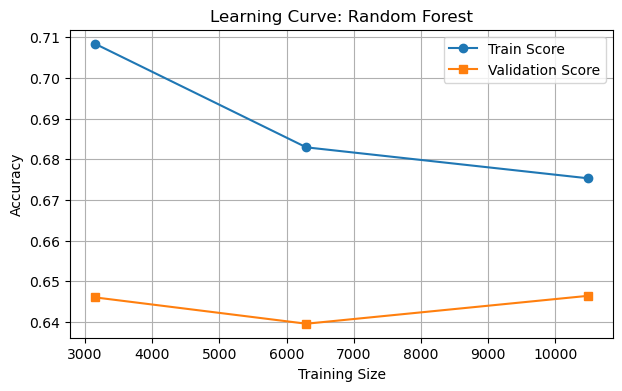

 Model is well-calibrated.


In [20]:
#   BIAS/VARIANCE DIAGNOSIS

print("\n Learning Curve & Bias/Variance Diagnosis...")

train_sizes, train_scores, val_scores = learning_curve(
    best_models['cls']['RF'], X_train_cls, y_train_cls, cv=3,
    scoring='accuracy', n_jobs=1, train_sizes=[0.3, 0.6, 1.0]
)

train_mean, val_mean = np.mean(train_scores, axis=1), np.mean(val_scores, axis=1)

plt.figure(figsize=(7,4))
plt.plot(train_sizes, train_mean, 'o-', label='Train Score')
plt.plot(train_sizes, val_mean, 's-', label='Validation Score')
plt.title('Learning Curve: Random Forest')
plt.xlabel('Training Size')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

gap = train_mean[-1] - val_mean[-1]
if gap > 0.05:
    print(" High Variance detected. Ensemble will help.")
else:
    print(" Model is well-calibrated.")

In [21]:
#  ENSEMBLE (COMMITTEE)
print("\n Building Committee of Models (Voting Ensemble)...")

# Regression Ensemble
voting_reg = VotingRegressor(estimators=[
    ('rf', best_models['reg']['RF']),
    ('svm', best_models['reg']['SVM']),
    ('knn', best_models['reg']['KNN'])
], weights=[1.5, 1.0, 0.5])
voting_reg.fit(X_train_reg, y_train_reg)

# Classification Ensemble
voting_cls = VotingClassifier(estimators=[
    ('rf', best_models['cls']['RF']),
    ('svm', best_models['cls']['SVM']),
    ('knn', best_models['cls']['KNN'])
], voting='soft', weights=[2, 1, 1])
voting_cls.fit(X_train_cls, y_train_cls)

# Evaluate on Test Set
y_pred_reg_final = voting_reg.predict(X_test_reg)
y_pred_cls_final = voting_cls.predict(X_test_cls)

a3_reg_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg_final))
a3_reg_r2 = r2_score(y_test_reg, y_pred_reg_final)
a3_cls_acc = accuracy_score(y_test_cls, y_pred_cls_final)

print(f" Ensemble Metrics -> RMSE: {a3_reg_rmse:.3f}, R²: {a3_reg_r2:.3f} | Acc: {a3_cls_acc:.3f}")


 Building Committee of Models (Voting Ensemble)...
 Ensemble Metrics -> RMSE: 3.034, R²: 0.852 | Acc: 0.844


In [22]:
#  [CELL 11] ASSIGNMENT 3: UNIFIED INFERENCE SYSTEM
print("\n Constructing Unified Inference System...")

class UnifiedScoutingSystem:
    def __init__(self, reg_model, cls_model):
        self.reg = reg_model
        self.cls = cls_model
        
    def predict(self, raw_X):
        val = self.reg.predict(raw_X)
        tier = self.cls.predict(raw_X)
        return pd.DataFrame({
            'Predicted_Value_M': np.round(val, 2),
            'Performance_Tier': tier
        }, index=raw_X.index)  

scouting_system = UnifiedScoutingSystem(voting_reg, voting_cls)

# Test on 3 players
sample_players = X_test_reg.sample(3)
print(" Sample Prediction:")
display(pd.concat([
    sample_players[['Age', 'Position', 'Total_Stats Score']],
    scouting_system.predict(sample_players)
], axis=1))


 Constructing Unified Inference System...
 Sample Prediction:


,Age,Position,Total_Stats Score,Predicted_Value_M,Performance_Tier
10522,24.0,CAM,1470.0,0.25,Low
19413,22.0,CM,1702.0,1.19,Mid
1739,34.0,CB,1814.0,2.63,Elite


In [23]:
#  STABILITY & JSON EXPORT

print("\n Final Stability Assessment & Exporting results.json...")

# Stability via Cross-Validation (3 folds for speed & reliability)
cv_reg = -cross_val_score(voting_reg, X_train_reg, y_train_reg, 
                          cv=KFold(3, shuffle=True, random_state=42), 
                          scoring='neg_root_mean_squared_error')
cv_cls = cross_val_score(voting_cls, X_train_cls, y_train_cls, 
                         cv=StratifiedKFold(3, shuffle=True, random_state=42), 
                         scoring='accuracy')

print(f" Regression CV: RMSE = {cv_reg.mean():.3f} ± {cv_reg.std():.3f}")
print(f" Classification CV: Acc  = {cv_cls.mean():.3f} ± {cv_cls.std():.3f}")

# Export results.json (Strictly following Assignment 3 requirements)
results = {
    "group_members": [
        "omar mohammed fathy 2406246399",
        "hassen ahmed 2406247253",
        "kareem elsaied ragab 2406245187",
        "marwan mahmud 2406247215",
        "yehia mohammed ahmed 2406246669",
        "farouk elsaied farouk 2406248088"
    ],
    "best_hyperparameters": best_params,
    "cv_stability": {
        "regression_rmse_mean": round(float(cv_reg.mean()), 4),
        "regression_rmse_std": round(float(cv_reg.std()), 4),
        "classification_accuracy_mean": round(float(cv_cls.mean()), 4),
        "classification_accuracy_std": round(float(cv_cls.std()), 4)
    }
}

with open('results.json', 'w') as f:
    json.dump(results, f, indent=4)

print("\n results.json exported successfully!")
print(" Assignment 3 complete and ready for submission!")


 Final Stability Assessment & Exporting results.json...
 Regression CV: RMSE = 2.661 ± 0.182
 Classification CV: Acc  = 0.840 ± 0.003

 results.json exported successfully!
 Assignment 3 complete and ready for submission!
